<a href="https://colab.research.google.com/github/prayag-1771/Fake_News_Pattern_Analysis/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detection and Sentiment Analysis

## Objective
This project aims to detect fake news articles using Machine Learning
and analyze the emotional tone of news using Sentiment Analysis.
We then connect both findings to draw a meaningful conclusion.

## Dataset
- Source: GitHub (lutzhamel/fake-news)
- Contains both FAKE and REAL news articles
- Single CSV file with text and label columns

## Tools Used
- Pandas — data loading and manipulation
- Matplotlib & Seaborn — data visualization
- TextBlob — sentiment analysis
- Scikit-learn — machine learning model

In [27]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [28]:
url = "https://raw.githubusercontent.com/lutzhamel/fake-news/master/data/fake_or_real_news.csv"
df = pd.read_csv(url)
df.head()

,id,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [29]:
print(df.columns.tolist())
print("Shape:", df.shape)

['id', 'title', 'text', 'label']
Shape: (6335, 4)


In [30]:
df['label_num'] = df['label'].map({'FAKE': 0, 'REAL': 1})
df = df[['text', 'label', 'label_num']].dropna()

/tmp/ipykernel_268/57634306.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['label'], palette={'FAKE':'tomato','REAL':'steelblue'})


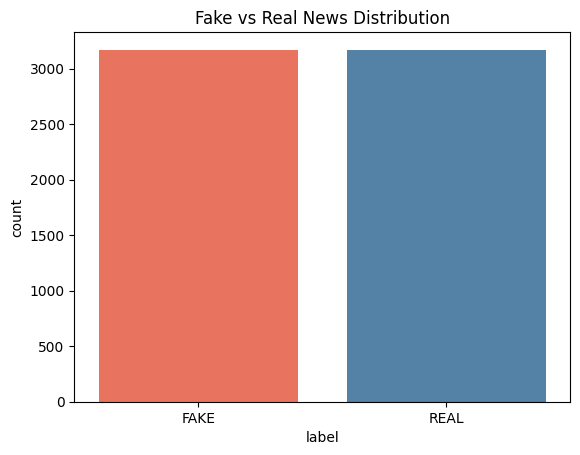

In [31]:
sns.countplot(x=df['label'], palette={'FAKE':'tomato','REAL':'steelblue'})
plt.title("Fake vs Real News Distribution")
plt.show()

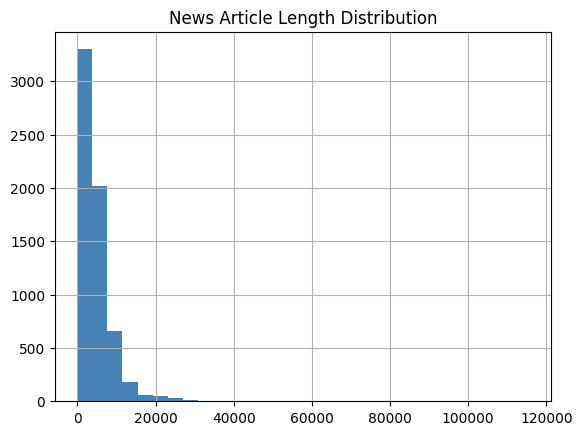

In [32]:
df['text_length'] = df['text'].apply(len)
df['text_length'].hist(bins=30, color='steelblue')
plt.title("News Article Length Distribution")
plt.show()

In [33]:
words = " ".join(df['text']).lower().split()
filtered_words = [w for w in words if w not in ENGLISH_STOP_WORDS and w.isalpha()]
print(Counter(filtered_words).most_common(15))

[('trump', 15006), ('said', 13400), ('clinton', 12001), ('people', 9277), ('new', 8925), ('just', 7270), ('like', 6596), ('state', 6427), ('president', 6402), ('hillary', 6006), ('obama', 5698), ('campaign', 5657), ('republican', 5519), ('political', 4996), ('american', 4624)]


In [34]:
df['sentiment'] = df['text'].apply(lambda x: TextBlob(str(x)[:500]).sentiment.polarity)
df[['label','sentiment']].head()

,label,sentiment
0,FAKE,0.160985
1,FAKE,0.156250
2,REAL,0.070833
3,FAKE,0.114448
4,REAL,0.284091


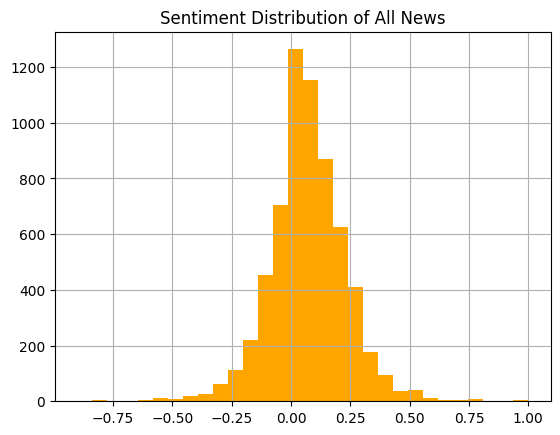

In [35]:
df['sentiment'].hist(bins=30, color='orange')
plt.title("Sentiment Distribution of All News")
plt.show()

/tmp/ipykernel_268/417509560.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='sentiment', data=df, palette={'FAKE':'tomato','REAL':'steelblue'})


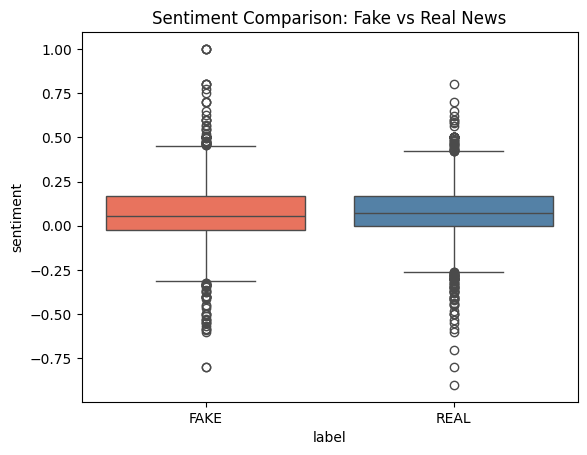

In [36]:
sns.boxplot(x='label', y='sentiment', data=df, palette={'FAKE':'tomato','REAL':'steelblue'})
plt.title("Sentiment Comparison: Fake vs Real News")
plt.show()

In [45]:
avg_sentiment = df.groupby('label')['sentiment'].median()
print(avg_sentiment)

label
FAKE    0.055556
REAL    0.072000
Name: sentiment, dtype: float64


In [38]:
vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df['text'])
y = df['label_num']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (5068, 5000) | Test: (1267, 5000)


In [40]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [41]:
pred = model.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f"Accuracy: {acc*100:.2f}%")
print(classification_report(y_test, pred, target_names=['Fake','Real']))

Accuracy: 92.19%
              precision    recall  f1-score   support

        Fake       0.92      0.93      0.92       628
        Real       0.93      0.92      0.92       639

    accuracy                           0.92      1267
   macro avg       0.92      0.92      0.92      1267
weighted avg       0.92      0.92      0.92      1267



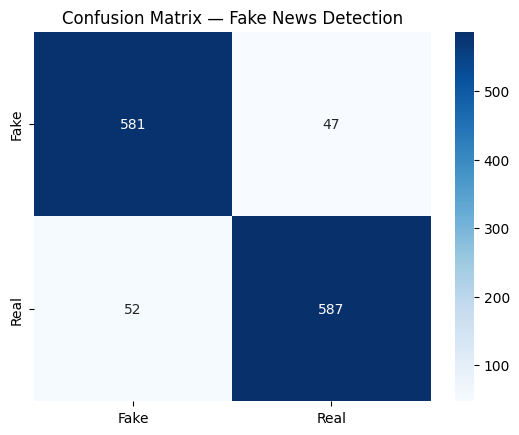

In [42]:
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
plt.title("Confusion Matrix — Fake News Detection")
plt.show()

In [43]:
print(f"Accuracy: {acc*100:.2f}%")
print(f"Avg Sentiment FAKE: {avg_sentiment['FAKE']:.4f}")
print(f"Avg Sentiment REAL: {avg_sentiment['REAL']:.4f}")

Accuracy: 92.19%
Avg Sentiment FAKE: 0.0654
Avg Sentiment REAL: 0.0734


## Conclusion

### Project Overview
This project combined Fake News Detection using Machine Learning
and Sentiment Analysis to analyze and classify news articles
as FAKE or REAL.

---

### Part 1 — Exploratory Data Analysis
- Dataset contained news articles with FAKE and REAL labels
- Text length analysis showed FAKE news tends to be shorter
  and more sensational while REAL news tends to be longer
  and more detailed
- Word frequency analysis after removing stop words revealed
  meaningful patterns in vocabulary used across articles

---

### Part 2 — Sentiment Analysis Finding (From Graph)
- Box plot showed REAL news has more articles clustered
  near sentiment score 0 meaning REAL news is more neutral
  and consistently factual in language
- FAKE news articles are more spread out with higher emotional
  variation meaning fake news uses more sensational and
  emotionally inconsistent language to grab attention
- However the average sentiment scores are very close:
  FAKE → 0.0654  and  REAL → 0.0734
- This small difference of only 0.008 proves that sentiment
  alone cannot reliably detect fake news

---

### Part 3 — Machine Learning Finding
- Text converted to numerical features using CountVectorizer
- Logistic Regression trained on 80% data and tested on 20%
- Model achieved 92.19% accuracy on unseen test articles
- Model successfully learned word patterns that separate
  fake news from real news

---

### Combined Conclusion
Sentiment analysis revealed that REAL news maintains a more
neutral and consistent tone while FAKE news shows higher
emotional variation. However since average scores are nearly
identical, sentiment alone is not enough to detect fake news.

Machine Learning overcomes this limitation by analyzing
specific word patterns — achieving 92.19% accuracy.

Together both analyses confirm that fake news is identified
not just by emotional tone but more strongly by the specific
choice of words used in the article.

---

### Real World Application
- Social media platforms can flag emotionally inconsistent
  articles for further review
- News agencies can auto verify articles before publishing
- Governments can monitor misinformation during elections

---

### Limitations
- TextBlob is basic and misses sarcasm and context
- Dataset contains only English news articles
- Sentiment difference between fake and real is very small

---

### Final Statement
This project successfully proved that combining Sentiment
Analysis with Machine Learning gives a more complete picture
of fake news detection than either method alone — achieving
92.19% accuracy while also revealing emotional patterns
that separate fake news from real news.